# Cold CO₂ injection and well interface loading

**Paper companion to [Hosking and Zhou (2025)](https://doi.org/10.1002/dug2.70014) · [NeqSim research issue #3959](https://github.com/equinor/neqsim/issues/3959).**

This reproducible study computes CO₂ fluid properties, steady injection well pressure and temperature, and a simplified shutdown profile with **NeqSim source at a pinned `master` commit**. It turns those outputs into labelled boundary data suitable for a separate thermo-hydro-mechanical (THM) well integrity solver. A published-result comparison makes the defect effect visible without claiming that NeqSim predicts interface damage.

**Learning objectives:** distinguish fluid pressure/temperature from casing–cement temperature and stress; examine the sensitivity to injection temperature and nitrogen contamination; check the geometry, units and model boundaries; export a transparent coupling handoff.

**Source:** Lee J. Hosking and Xiangming Zhou, *Damage modeling of CO₂ injection well interfaces under coupled thermal, hydraulic and mechanical behavior*, Deep Underground Science and Engineering (2025), DOI [10.1002/dug2.70014](https://doi.org/10.1002/dug2.70014). The paper considers a 2D plane strain section above the injection interval at an imposed **20 MPa** and **10 or 20 °C** for **30 days**. The authors report damage at the casing–cement interface in the 10 °C cases and show the effect of a pre-existing 45° debond. These conditions motivate the *boundary cases* below; geometry, flow rate, impurity level and formation gradient in this notebook are **synthetic teaching inputs**, not paper inputs.

**Interpretation boundary:** a flowing wellbore profile is not the paper's 2D plane strain model. Fluid temperature is not the casing–cement interface temperature. NeqSim calculates neither cohesive traction–separation damage nor microannulus aperture here; published apertures are quoted strictly as external reference data.

## 1. Reproducible source build

The first run in Colab installs Python dependencies, checks out the pinned NeqSim `master` commit, builds its shaded Java JAR, and verifies the runtime class origin. A local validated build can be supplied with `NEQSIM_SOURCE_ROOT` and `NEQSIM_SOURCE_JAR` to avoid rebuilding. Java 17+ is needed. The pinned revision is printed alongside the JAR SHA-256.

In [1]:
import hashlib
import os
from pathlib import Path
import subprocess
import sys

NEQSIM_SOURCE_REF = "de26ac5eb57d8981de98d6c26b3c810367f5d6c8"
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"

try:
    import jpype
except ImportError:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "JPype1==1.7.1"],
        check=True,
    )
    import jpype

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

source_root = Path(os.environ.get("NEQSIM_SOURCE_ROOT", "neqsim-paper-source")).resolve()
if not source_root.exists():
    subprocess.run(
        [
            "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
            "--no-checkout", "https://github.com/equinor/neqsim.git", str(source_root),
        ],
        check=True,
    )
    subprocess.run(
        ["git", "sparse-checkout", "set", "src/main", ".mvn", "pom.xml", "mvnw"],
        cwd=source_root,
        check=True,
    )
    subprocess.run(
        ["git", "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF],
        cwd=source_root,
        check=True,
    )
    subprocess.run(["git", "checkout", "FETCH_HEAD"], cwd=source_root, check=True)

source_sha = subprocess.check_output(
    ["git", "rev-parse", "HEAD"], cwd=source_root, text=True
).strip()
assert source_sha == NEQSIM_SOURCE_REF, "The source checkout does not match the pinned commit"

source_jar = Path(
    os.environ.get("NEQSIM_SOURCE_JAR", source_root / "target" / "neqsim-3.22.0.jar")
).resolve()
if not source_jar.is_file():
    subprocess.run(
        [
            "./mvnw", "-q", "-DskipTests", "-Dmaven.test.skip=true",
            "-Dcheckstyle.skip", "-Dspotless.skip=true",
            "-Dmaven.javadoc.skip=true", "package",
        ],
        cwd=source_root,
        check=True,
    )
assert source_jar.is_file(), f"Source-built JAR missing: {source_jar}"
jar_sha256 = hashlib.sha256(source_jar.read_bytes()).hexdigest()
assert not jpype.isJVMStarted(), "Restart the kernel before selecting a new NeqSim JAR"
jpype.addClassPath(str(source_jar))
jpype.startJVM("-Xrs", "-Xmx2g", convertStrings=True)

SystemPrEos = jpype.JClass("neqsim.thermo.system.SystemPrEos")
ThermodynamicOperations = jpype.JClass(
    "neqsim.thermodynamicoperations.ThermodynamicOperations"
)
Stream = jpype.JClass("neqsim.process.equipment.stream.Stream")
PipeBeggsAndBrills = jpype.JClass(
    "neqsim.process.equipment.pipeline.PipeBeggsAndBrills"
)
TransientWellbore = jpype.JClass(
    "neqsim.process.equipment.pipeline.TransientWellbore"
)
CO2InjectionWellAnalyzer = jpype.JClass(
    "neqsim.process.equipment.pipeline.CO2InjectionWellAnalyzer"
)

for java_class in (
    SystemPrEos, PipeBeggsAndBrills, TransientWellbore, CO2InjectionWellAnalyzer
):
    class_origin = str(java_class.class_.getProtectionDomain().getCodeSource().getLocation())
    assert source_jar.name in class_origin, (java_class, class_origin)

print("NeqSim source commit:", source_sha)
print("Source-built JAR SHA-256:", jar_sha256)
print("Java version:", jpype.java.lang.System.getProperty("java.version"))
print("Python version:", sys.version.split()[0])
print("Selected class origin:", class_origin)

NeqSim source commit: de26ac5eb57d8981de98d6c26b3c810367f5d6c8
Source-built JAR SHA-256: 5d382156b138c4529a61e087999a42b33991d3423c58e86de172b4de775e81c0
Java version: 17.0.20
Python version: 3.12.14
Selected class origin: file:/workspace/scratch/11a1fc6b5bcd/.neqsim-source-sparse/target/neqsim-3.22.0.jar


## 2. Synthetic case definitions and phase/property checks

Two fluid recipes are considered: pure CO₂ and CO₂ with 1 mol% nitrogen. The imposed **200 bara** is an illustrative approximation to the paper's **20 MPa** boundary pressure, with a distinction between absolute pressure and pressure relative to the surroundings. The 10 and 20 °C points are paper temperatures. The nitrogen fraction is our sensitivity case.

At each state NeqSim uses Peng–Robinson (`SystemPrEos`) with the `classic` mixing rule and an equilibrium TP flash. Density and viscosity are fluid properties, not interface properties. Multi-phase states are flagged and excluded from the single-phase property interpretation.

In [2]:
CASE_TEMPERATURES_C = (10.0, 20.0)
CASE_PRESSURE_BARA = 200.0
NITROGEN_MOLE_FRACTIONS = (0.0, 0.01)


def make_fluid(temperature_c, pressure_bara, nitrogen_fraction):
    fluid = SystemPrEos(temperature_c + 273.15, pressure_bara)
    fluid.addComponent("CO2", 1.0 - nitrogen_fraction)
    if nitrogen_fraction > 0.0:
        fluid.addComponent("nitrogen", nitrogen_fraction)
    fluid.setMixingRule("classic")
    return fluid


def equilibrium_properties(temperature_c, pressure_bara, nitrogen_fraction):
    fluid = make_fluid(temperature_c, pressure_bara, nitrogen_fraction)
    ThermodynamicOperations(fluid).TPflash()
    fluid.initPhysicalProperties()
    density = float(fluid.getDensity("kg/m3"))
    viscosity = float(fluid.getViscosity("kg/msec"))
    phases = int(fluid.getNumberOfPhases())
    assert density > 0.0 and viscosity > 0.0 and phases >= 1
    return {
        "temperature_C": temperature_c,
        "pressure_bara": pressure_bara,
        "nitrogen_mol_percent": 100.0 * nitrogen_fraction,
        "phases": phases,
        "density_kg_m3": density,
        "viscosity_mPa_s": viscosity * 1000.0,
    }


properties = pd.DataFrame(
    equilibrium_properties(temperature, CASE_PRESSURE_BARA, nitrogen)
    for nitrogen in NITROGEN_MOLE_FRACTIONS
    for temperature in CASE_TEMPERATURES_C
)
assert (properties["phases"] == 1).all()
display(properties.round(4))

,temperature_C,pressure_bara,nitrogen_mol_percent,phases,density_kg_m3,viscosity_mPa_s
0,10.0,200.0,0.0,1,964.7635,0.1078
1,20.0,200.0,0.0,1,914.6999,0.0962
2,10.0,200.0,1.0,1,954.4890,0.1051
3,20.0,200.0,1.0,1,903.8531,0.0938


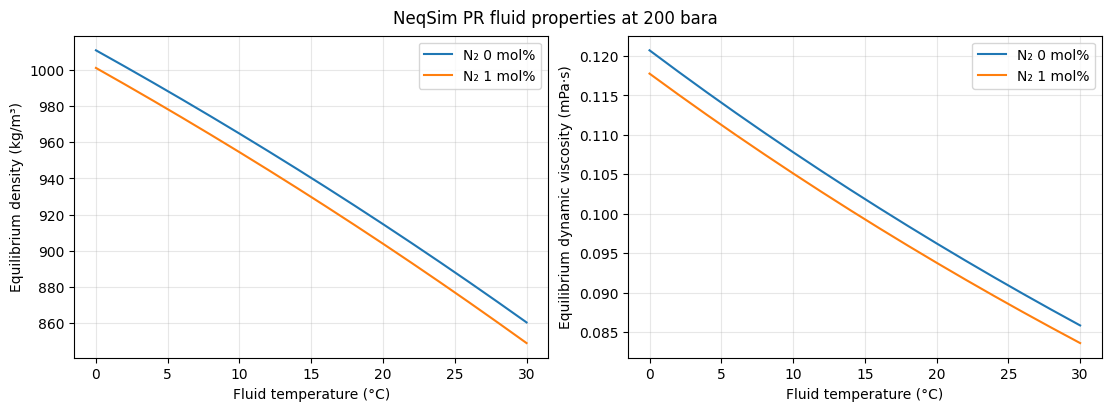

In [3]:
temperature_grid_c = np.arange(0.0, 31.0, 2.0)
property_sweep = pd.DataFrame(
    equilibrium_properties(temperature, CASE_PRESSURE_BARA, nitrogen)
    for nitrogen in NITROGEN_MOLE_FRACTIONS
    for temperature in temperature_grid_c
)
assert (property_sweep["phases"] == 1).all()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for nitrogen, group in property_sweep.groupby("nitrogen_mol_percent"):
    label = f"N₂ {nitrogen:.0f} mol%"
    axes[0].plot(group["temperature_C"], group["density_kg_m3"], label=label)
    axes[1].plot(group["temperature_C"], group["viscosity_mPa_s"], label=label)
for axis in axes:
    axis.set_xlabel("Fluid temperature (°C)")
    axis.grid(alpha=0.3)
    axis.legend()
axes[0].set_ylabel("Equilibrium density (kg/m³)")
axes[1].set_ylabel("Equilibrium dynamic viscosity (mPa·s)")
fig.suptitle("NeqSim PR fluid properties at 200 bara")
plt.show()

## 3. Flowing injection well conditions

The synthetic demonstration uses 1,500 m tubing length and downward elevation, 0.1571 m tubing ID, 150,000 kg/h, and a formation temperature increasing from 4 to 56.5 °C. `PipeBeggsAndBrills` produces fluid pressure and temperature profiles. The formation-gradient and heat-transfer choices are illustrative: measured depth equals vertical depth, and no casing/cement conduction or reservoir backpressure is represented. At 200 bara wellhead pressure the flowing bottom-hole pressure rises hydrostatically; this **must not** be mistaken for the paper's uniform 20 MPa casing load.

In [4]:
WELL_DEPTH_M = 1500.0
TUBING_ID_M = 0.1571
ROUGHNESS_M = 4.5e-5
MASS_FLOW_KG_H = 150000.0
FORMATION_TOP_C = 4.0
FORMATION_GRADIENT_C_M = 0.035
N_SEGMENTS = 20
SCENARIO_NITROGEN = 0.01


def run_injection_well(inlet_temperature_c):
    feed_fluid = make_fluid(
        inlet_temperature_c, CASE_PRESSURE_BARA, SCENARIO_NITROGEN
    )
    feed = Stream(f"injection-{inlet_temperature_c:g}C", feed_fluid)
    feed.setFlowRate(MASS_FLOW_KG_H, "kg/hr")
    feed.run()

    well = PipeBeggsAndBrills(f"well-{inlet_temperature_c:g}C", feed)
    well.setPipeWallRoughness(ROUGHNESS_M)
    well.setLength(WELL_DEPTH_M)
    well.setElevation(-WELL_DEPTH_M)
    well.setDiameter(TUBING_ID_M)
    well.setNumberOfIncrements(N_SEGMENTS)
    well.setFormationTemperatureGradient(
        FORMATION_TOP_C, -FORMATION_GRADIENT_C_M, "C"
    )
    well.setHeatTransferMode(
        PipeBeggsAndBrills.HeatTransferMode.ESTIMATED_INNER_H
    )
    well.run()

    depth_m = np.linspace(0.0, WELL_DEPTH_M, N_SEGMENTS + 1)
    pressure_bara = np.asarray(well.getPressureProfile(), dtype=float)
    temperature_c = np.asarray(well.getTemperatureProfile(), dtype=float) - 273.15
    assert len(depth_m) == len(pressure_bara) == len(temperature_c)
    assert np.isfinite(pressure_bara).all() and np.isfinite(temperature_c).all()

    profile = pd.DataFrame(
        {
            "scenario_inlet_C": inlet_temperature_c,
            "depth_m": depth_m,
            "fluid_pressure_bara": pressure_bara,
            "fluid_temperature_C": temperature_c,
            "formation_temperature_C": FORMATION_TOP_C + FORMATION_GRADIENT_C_M * depth_m,
        }
    )
    return feed, well, profile


well_cases = {
    temperature: run_injection_well(temperature)
    for temperature in CASE_TEMPERATURES_C
}
steady_profiles = pd.concat(
    [case[2] for case in well_cases.values()], ignore_index=True
)
well_summary = steady_profiles.groupby("scenario_inlet_C", as_index=False).tail(1)
display(well_summary.round(2))
assert (well_summary["fluid_pressure_bara"] > CASE_PRESSURE_BARA).all()

,scenario_inlet_C,depth_m,fluid_pressure_bara,fluid_temperature_C,formation_temperature_C
20,10.0,1500.0,329.93,56.6,56.5
41,20.0,1500.0,329.50,56.6,56.5


### Integrated NeqSim analyzer cross-check

`CO2InjectionWellAnalyzer` combines a steady design case with phase and shutdown screens. We cross-check its design-case pressure and temperature against the directly exposed pipe profiles. Its `isSafeToOperate()` flag only confirms a single-phase design-case outlet in the current implementation; **it is not a cement/well-integrity acceptance criterion**. A registered impurity threshold can be ignored by the flag ([NeqSim #3964](https://github.com/equinor/neqsim/issues/3964)). The analyzer's preset phase scan spans 10–100 bara and must not be treated as a 200 bara design envelope.

In [5]:
analyzer = CO2InjectionWellAnalyzer("CO2-paper-companion")
analyzer.setFluid(make_fluid(10.0, CASE_PRESSURE_BARA, SCENARIO_NITROGEN))
analyzer.setWellGeometry(WELL_DEPTH_M, TUBING_ID_M, ROUGHNESS_M)
analyzer.setOperatingConditions(CASE_PRESSURE_BARA, 10.0, MASS_FLOW_KG_H)
analyzer.setFormationTemperature(
    FORMATION_TOP_C, FORMATION_TOP_C + FORMATION_GRADIENT_C_M * WELL_DEPTH_M
)
analyzer.runFullAnalysis()
analyzer_design = analyzer.getResults().get("design_case")
direct_tail = well_cases[10.0][2].iloc[-1]
assert abs(float(analyzer_design.get("BHP_bara")) - direct_tail["fluid_pressure_bara"]) < 1e-5
assert abs(float(analyzer_design.get("BHT_C")) - direct_tail["fluid_temperature_C"]) < 1e-5
display(pd.DataFrame([{
    "design_BHP_bara": float(analyzer_design.get("BHP_bara")),
    "design_BHT_C": float(analyzer_design.get("BHT_C")),
    "fluid_phases_at_outlet": int(analyzer_design.get("n_phases")),
    "single_phase_design_flag": bool(analyzer.isSafeToOperate()),
}]).round(3))

,design_BHP_bara,design_BHT_C,fluid_phases_at_outlet,single_phase_design_flag
0,329.933,56.604,1,True


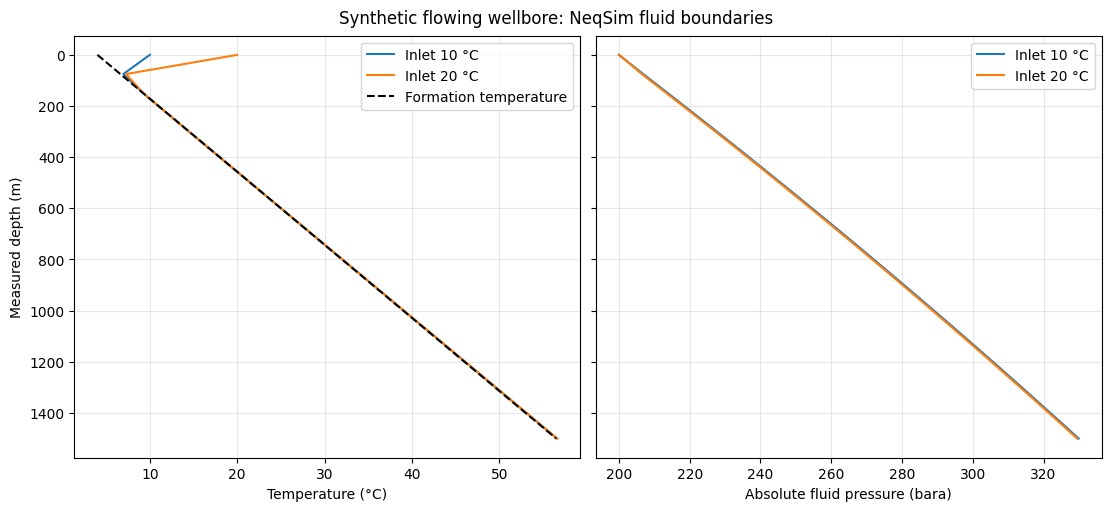

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True, constrained_layout=True)
for inlet_temperature, (_, _, profile) in well_cases.items():
    axes[0].plot(
        profile["fluid_temperature_C"], profile["depth_m"],
        label=f"Inlet {inlet_temperature:.0f} °C",
    )
    axes[1].plot(
        profile["fluid_pressure_bara"], profile["depth_m"],
        label=f"Inlet {inlet_temperature:.0f} °C",
    )
axes[0].plot(
    steady_profiles.loc[steady_profiles["scenario_inlet_C"] == 10.0,
                        "formation_temperature_C"],
    steady_profiles.loc[steady_profiles["scenario_inlet_C"] == 10.0, "depth_m"],
    "k--", label="Formation temperature",
)
axes[0].set_xlabel("Temperature (°C)")
axes[1].set_xlabel("Absolute fluid pressure (bara)")
axes[0].set_ylabel("Measured depth (m)")
axes[0].invert_yaxis()
for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend()
fig.suptitle("Synthetic flowing wellbore: NeqSim fluid boundaries")
plt.show()

## 4. Temperature mismatch as an input to THM analysis

At each depth, the **fluid-to-formation difference** is $\Delta T_f = T_{\mathrm{fluid}}-T_{\mathrm{formation}}$, in K. This is a boundary-condition indicator, **not** a prediction of casing temperature, cement stress, bond failure or microannulus aperture. A specialist THM model must resolve transient heat conduction, pore pressure, casing/cement/rock mechanics, initial defects, cohesive strengths, and traction–separation laws. The paper's 30-day interface loading must be prescribed and independently verified there.

,scenario_inlet_C,depth_m,fluid_pressure_bara,fluid_temperature_C,formation_temperature_C,fluid_formation_delta_K
0,10.0,0.0,200.00,10.00,4.00,6.00
10,10.0,750.0,267.69,30.28,30.25,0.03
20,10.0,1500.0,329.93,56.60,56.50,0.10
21,20.0,0.0,200.00,20.00,4.00,16.00
31,20.0,750.0,267.28,30.28,30.25,0.03
41,20.0,1500.0,329.50,56.60,56.50,0.10


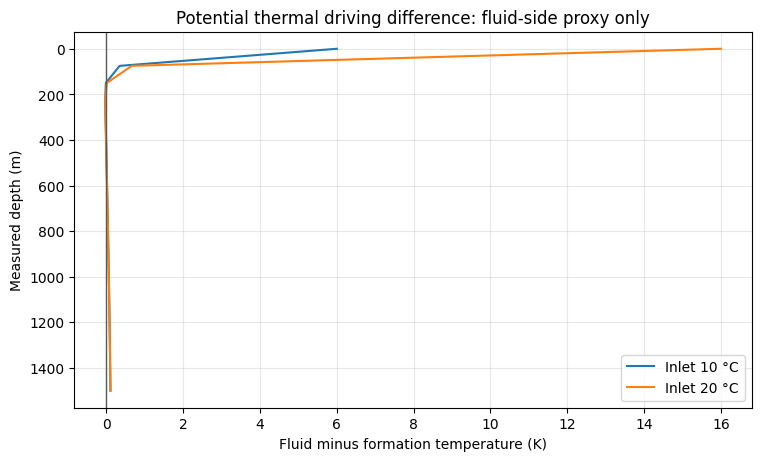

In [7]:
steady_profiles["fluid_formation_delta_K"] = (
    steady_profiles["fluid_temperature_C"]
    - steady_profiles["formation_temperature_C"]
)
selected_depths_m = (0.0, 750.0, 1500.0)
boundary_points = steady_profiles[
    steady_profiles["depth_m"].isin(selected_depths_m)
].copy()
display(boundary_points.round(2))

fig, axis = plt.subplots(figsize=(7.5, 4.5), constrained_layout=True)
for inlet_temperature, profile in steady_profiles.groupby("scenario_inlet_C"):
    axis.plot(
        profile["fluid_formation_delta_K"], profile["depth_m"],
        label=f"Inlet {inlet_temperature:.0f} °C",
    )
axis.axvline(0.0, color="0.35", linewidth=1)
axis.set_xlabel("Fluid minus formation temperature (K)")
axis.set_ylabel("Measured depth (m)")
axis.set_title("Potential thermal driving difference: fluid-side proxy only")
axis.invert_yaxis()
axis.grid(alpha=0.3)
axis.legend()
plt.show()

## 5. Shutdown sensitivity (separate short-time model)

`TransientWellbore` uses an exponentially relaxing **fluid** temperature toward a linear geothermal profile and an approximate constant-density hydrostatic profile. We use a 48-hour shutdown illustration with a 24-hour time constant; the time constant is an **assumed input**, not fitted to the paper. This is neither the paper's 30-day injection calculation nor a radial heat-conduction or damage solution. Keep the phase count to detect a change in fluid state.

In [8]:
shutdown_rows = []
for inlet_temperature, (feed, _, _) in well_cases.items():
    shutdown = TransientWellbore(f"shutdown-{inlet_temperature:g}C", feed)
    shutdown.setWellDepth(WELL_DEPTH_M)
    shutdown.setTubingDiameter(TUBING_ID_M)
    shutdown.setFormationTemperature(
        FORMATION_TOP_C + 273.15,
        FORMATION_TOP_C + FORMATION_GRADIENT_C_M * WELL_DEPTH_M + 273.15,
    )
    shutdown.setShutdownCoolingRate(24.0)
    shutdown.setNumberOfSegments(6)
    shutdown.runShutdownSimulation(48.0, 6.0)

    for snapshot in shutdown.getSnapshots():
        for segment_index in (0, 3, 6):
            shutdown_rows.append(
                {
                    "inlet_C": inlet_temperature,
                    "time_h": float(snapshot.timeHours),
                    "depth_m": float(snapshot.depths[segment_index]),
                    "fluid_temperature_C": (
                        float(snapshot.temperatures[segment_index]) - 273.15
                    ),
                    "fluid_pressure_bara": float(snapshot.pressures[segment_index]),
                    "phases": int(snapshot.numberOfPhases[segment_index]),
                }
            )

shutdown_results = pd.DataFrame(shutdown_rows)
assert (shutdown_results["phases"] == 1).all()
assert shutdown_results["fluid_temperature_C"].notna().all()
display(shutdown_results[shutdown_results["time_h"].isin((0.0, 24.0, 48.0))].round(2))

,inlet_C,time_h,depth_m,fluid_temperature_C,fluid_pressure_bara,phases
0,10.0,0.0,0.0,10.00,200.00,1
1,10.0,0.0,750.0,23.12,270.23,1
2,10.0,0.0,1500.0,36.25,340.45,1
12,10.0,24.0,0.0,6.21,200.00,1
13,10.0,24.0,750.0,27.63,270.23,1
14,10.0,24.0,1500.0,49.05,340.45,1
24,10.0,48.0,0.0,4.81,200.00,1
25,10.0,48.0,750.0,29.29,270.23,1
26,10.0,48.0,1500.0,53.76,340.45,1
27,20.0,0.0,0.0,20.00,200.00,1


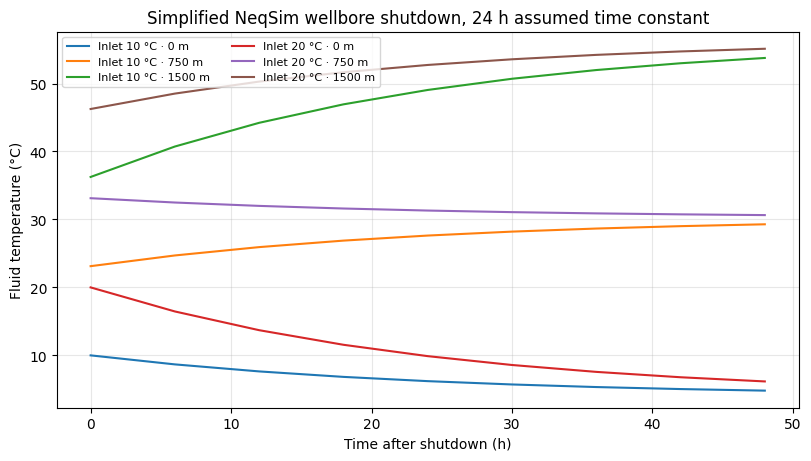

In [9]:
fig, axis = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
for (inlet_temperature, depth_m), group in shutdown_results.groupby(
    ["inlet_C", "depth_m"]
):
    axis.plot(
        group["time_h"], group["fluid_temperature_C"],
        label=f"Inlet {inlet_temperature:.0f} °C · {depth_m:.0f} m",
    )
axis.set_xlabel("Time after shutdown (h)")
axis.set_ylabel("Fluid temperature (°C)")
axis.set_title("Simplified NeqSim wellbore shutdown, 24 h assumed time constant")
axis.grid(alpha=0.3)
axis.legend(ncol=2, fontsize=8)
plt.show()

## 6. Published results: comparison, not calibration

The following values are **reported by Hosking and Zhou**, not calculated by NeqSim or predicted by this notebook. For the 10 °C cases, the initially intact casing–cement interface begins damage after 4 days and reaches a peak aperture of 0.037 mm after 30 days. The initially defective case begins damage after 2.75 days and reaches 0.077 mm. The authors' 20 °C cases did not develop interface damage under their selected conditions. Their casing–cement damage did **not** imply cement–formation debonding. A simple cubic-law aperture ratio is a *conditional transport analogy* for an already connected laminar slot; it is not a leakage rate, because azimuthal extent, aperture distribution, path continuity and pressure gradient are not represented.

Reported peak-aperture ratio: 2.08 ×
Conditional cubic-law local transmissivity ratio: 9.01 ×


,case,damage_start_day,peak_aperture_mm
0,"Intact, 10 °C",4.00,0.037
1,"Pre-debonded, 10 °C",2.75,0.077
2,"Intact, 20 °C",NaN,NaN
3,"Pre-debonded, 20 °C",NaN,NaN


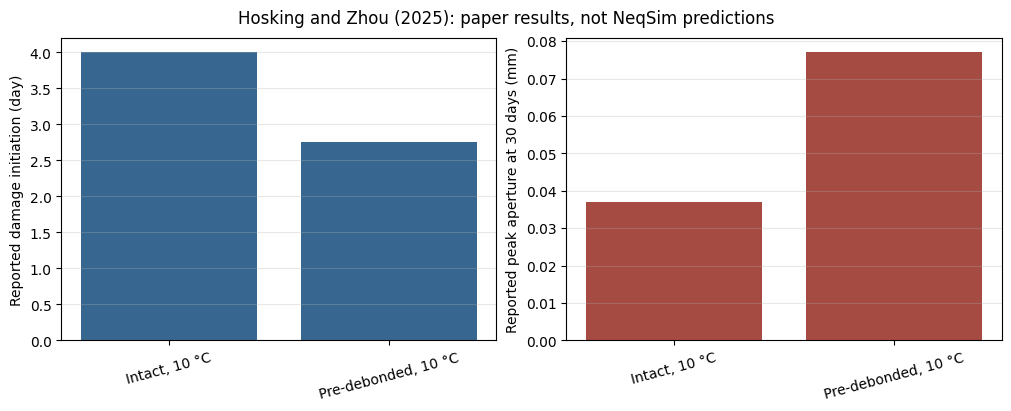

In [10]:
paper_results = pd.DataFrame(
    [
        {"case": "Intact, 10 °C", "damage_start_day": 4.0,
         "peak_aperture_mm": 0.037},
        {"case": "Pre-debonded, 10 °C", "damage_start_day": 2.75,
         "peak_aperture_mm": 0.077},
        {"case": "Intact, 20 °C", "damage_start_day": np.nan,
         "peak_aperture_mm": np.nan},
        {"case": "Pre-debonded, 20 °C", "damage_start_day": np.nan,
         "peak_aperture_mm": np.nan},
    ]
)
aperture_ratio = 0.077 / 0.037
conditional_transmissivity_ratio = aperture_ratio ** 3
display(paper_results)
print(f"Reported peak-aperture ratio: {aperture_ratio:.2f} ×")
print(
    "Conditional cubic-law local transmissivity ratio: "
    f"{conditional_transmissivity_ratio:.2f} ×"
)
assert 2.0 < aperture_ratio < 2.2

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
cold_cases = paper_results.iloc[:2]
axes[0].bar(cold_cases["case"], cold_cases["damage_start_day"], color="#376791")
axes[1].bar(cold_cases["case"], cold_cases["peak_aperture_mm"], color="#a64b41")
axes[0].set_ylabel("Reported damage initiation (day)")
axes[1].set_ylabel("Reported peak aperture at 30 days (mm)")
for axis in axes:
    axis.grid(axis="y", alpha=0.3)
    axis.tick_params(axis="x", rotation=15)
fig.suptitle("Hosking and Zhou (2025): paper results, not NeqSim predictions")
plt.show()

## 7. Export a fluid-side coupling handoff

The CSV and JSON carry the **synthetic wellbore fluid boundary** with explicit depth, pressure and temperature units, source commit and scope. A THM analysis must choose a defensible casing/cement geometry and thermal contact law, then translate fluid-side quantities to wall loads. The standalone paper reference table is exported separately; it must not be confused with NeqSim outputs. The files are also inspectable in the notebook.

In [11]:
import json

output_dir = Path("co2_injection_interface_outputs")
output_dir.mkdir(exist_ok=True)
steady_profiles.to_csv(output_dir / "fluid_boundary_steady.csv", index=False)
shutdown_results.to_csv(output_dir / "fluid_boundary_shutdown.csv", index=False)
paper_results.to_csv(output_dir / "paper_reported_reference.csv", index=False)

handoff = {
    "schema": "educational-fluid-boundary-v1",
    "source_repository": "https://github.com/equinor/neqsim",
    "source_commit": source_sha,
    "source_jar_sha256": jar_sha256,
    "paper_doi": "10.1002/dug2.70014",
    "fluid_model": "NeqSim SystemPrEos, classic mixing rule, TP equilibrium",
    "pressure_unit": "bara (absolute)",
    "temperature_unit": "degC (fluid, not casing-cement)",
    "depth_unit": "m (positive downward measured depth)",
    "flow_unit": "kg/hr",
    "scenario_assumptions": {
        "geometry": "synthetic 1500 m vertical tubing, 0.1571 m ID",
        "flow_kg_hr": MASS_FLOW_KG_H,
        "nitrogen_mole_fraction": SCENARIO_NITROGEN,
        "formation_top_C": FORMATION_TOP_C,
        "formation_gradient_C_per_m": FORMATION_GRADIENT_C_M,
        "shutdown_time_constant_h": 24.0,
    },
    "files": ["fluid_boundary_steady.csv", "fluid_boundary_shutdown.csv"],
    "excluded_outputs": [
        "casing or cement temperature", "interface stress", "damage onset",
        "microannulus aperture", "qualified leakage rate",
    ],
}
(output_dir / "handoff.json").write_text(json.dumps(handoff, indent=2))
display(pd.DataFrame([handoff["scenario_assumptions"]]).T.rename(columns={0: "value"}))
output_names = sorted(path.name for path in output_dir.iterdir())
print(json.dumps({"source_commit": source_sha, "files": output_names}, indent=2))
print("Steady boundary preview:")
display(steady_profiles.head(4).round(3))

{
  "source_commit": "de26ac5eb57d8981de98d6c26b3c810367f5d6c8",
  "files": [
    "fluid_boundary_shutdown.csv",
    "fluid_boundary_steady.csv",
    "handoff.json",
    "paper_reported_reference.csv"
  ]
}
Steady boundary preview:


,value
geometry,"synthetic 1500 m vertical tubing, 0.1571 m ID"
flow_kg_hr,150000.0
nitrogen_mole_fraction,0.01
formation_top_C,4.0
formation_gradient_C_per_m,0.035
shutdown_time_constant_h,24.0


,scenario_inlet_C,depth_m,fluid_pressure_bara,fluid_temperature_C,formation_temperature_C,fluid_formation_delta_K
0,10.0,0.0,200.000,10.000,4.000,6.000
1,10.0,75.0,206.848,6.968,6.625,0.343
2,10.0,150.0,213.836,9.234,9.250,-0.016
3,10.0,225.0,220.777,11.842,11.875,-0.033


## Engineering conclusions and limitations

1. **NeqSim supplies fluid-side boundary data.** The run above provides source-traceable PR densities, viscosities, and synthetic steady/shutdown wellbore $P,T$ profiles. These are inputs to an integrity study, not well integrity findings.
2. **The paper's damage result is external evidence.** For its 20 MPa, 30-day cases, the authors report damage at 10 °C and no damage at 20 °C; an initial defect advanced onset and more than doubled the reported peak aperture. The paper's model, material parameters and geometric defect are needed to reproduce these outcomes.
3. **Next research implementation:** couple validated NeqSim wall-side $P,T$ histories to a separate, verified radial heat transfer and THM/cohesive interface solver, with explicit material provenance, contact conditions, grid/time convergence, analytical checks and the paper's four reference cases. This missing THM/cohesive physics should not be represented by a threshold on fluid temperature or by the current simplified shutdown model. Tracked as [NeqSim issue #3959](https://github.com/equinor/neqsim/issues/3959).

**Provenance and limits:** Synthetic flow and composition; PR equilibrium, no EOS benchmark here; no radial wall conduction, poroelasticity, defects, cement failure or leakage-rate prediction. The `TransientWellbore` model relaxes fluid temperature exponentially, uses a constant-density hydrostatic approximation and is shown for 48 h. The paper used a 30-day coupled THM calculation of a caprock well section. The analyzer alarm contract is separately tracked in [#3964](https://github.com/equinor/neqsim/issues/3964). Assess any site-specific design using measured composition, geology, well geometry, thermal contacts and validated integrity tools.